# Galactic-foreground modulation: Fig. 7 with the `cyclo` (pack 2) parameters

**Goal (stage 1, no wavelets yet).** Reproduce the time-domain amplitude envelope of the Galactic foreground (GF), i.e.
Fig. 7 of Buscicchio et al., *Test for LISA foreground Gaussianity and stationarity: galactic white-dwarf binaries*
(EPJC 2025, [arXiv:2410.08263](https://arxiv.org/abs/2410.08263)), using the original (chunked) `bahamas` code and the
injection Riccardo used for the run in `cyclo_riccardo/cyclo/`. That run belongs to Buscicchio, Pozzoli, Chirico & Sesana,
*The first year of LISA Galactic foreground* ([arXiv:2511.03604](https://arxiv.org/abs/2511.03604)).

**How the pieces fit together**

* **Fig. 7 (paper 1)** shows 4 yr of simulated GF in TDI A and E, with the envelope $\pm H_{A,E}(t)$ on top.
  The envelope comes from a bivariate-Gaussian sky distribution of DWDs (Eqs. 28–32). In `bahamas` this is
  `psd_response.modulation.envelopes_gaussian`, which returns $M_{A,E}(t)$.
* **Paper 2** treats the GF as *quasi-stationary* over chunks. The chunk-$c$ PSD is
  $\bar M^c_j\,S_{\rm GF}(f)$, where $\bar M^c_j = \frac{1}{t_E-t_S}\int_{t_S}^{t_E} M_j^2(t)\,dt$ (Eq. 14).
  This is `psd_response.average_envelope.average_envelopes_gaussian`, used by `galactic_DWD_time`.
* **`cyclo_riccardo/cyclo/`** is one of those runs: **packet 2** of the "first year, two weeks" study. It covers
  $T=30$ d split into two 15 d chunks, with the Gamma likelihood on 1000 log-binned frequencies (0.1–29 mHz) and nessai.
  Packet $n$ holds $n$ chunks of about two weeks (Table I and Fig. 2 of paper 2). The GF knee parameters in the yaml are
  Eqs. 12–13 evaluated at $T_{\rm obs}=30$ d. Fig. A2 shows the *differential* version of the same two-week segmentation,
  with the same injection: packs 7, 16 and 26.

**Notebook outline**
1. Load Riccardo's config and injection.
2. Instantaneous envelope $M^2(t)$ against the chunk averages $\bar M^c$ that the original code uses.
3. **Fig. 7 reproduction**: a modulated time-domain GF realisation, $x_j(t) = M_j(t)\,n_j(t)$.
4. Consistency check: the original `SignalProcessor` pack-2 data, plus the modulation recovered from the time series, against the model.
5. Riccardo's pack-2 posterior, mapped to a posterior-predictive envelope.
6. Fig. A2 / Fig. 6 context: where the packs sit on $M^2(t)$ and on $d^2M^2/dt^2$.
7. Save the true envelope and data products for the wavelet stage.

In [1]:
from pathlib import Path
import numpy as np
import yaml
import h5py
import corner
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
CYCLO = ROOT / 'cyclo_riccardo' / 'cyclo'
OUT = ROOT / 'data' / 'cyclo_fig7_outputs'
OUT.mkdir(exist_ok=True)

from bahamas.backend_context import initialize_backend
initialize_backend(use_jax=True)
import jax
jax.config.update('jax_enable_x64', True)

from bahamas.psd_response.modulation import envelopes_gaussian
from bahamas.psd_response.average_envelope import average_envelopes_gaussian
from bahamas.psd_strain import psd_galaxy as gal
from bahamas.psd_strain import psd_function as psd
from bahamas.method import setting_data
from bahamas import bahamas_data

YEAR = gal.year          # 31557600 s, the same constant the GF model uses
DAY = 86400.
SEED = 42

# palette: data in light blue, truth/model in ink, chunked quantities in orange
C_DATA, C_DATA_DARK, C_CHUNK, C_CHUNK2, C_INK, C_MUTED = '#86b6ef', '#2a78d6', '#eb6834', '#1baf7a', '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 1.5, 'legend.frameon': False})

def bottom_legend(fig, ax, ncol):
    # shared legend under the panels, so it never covers data
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    fig.legend(*ax.get_legend_handles_labels(), loc='lower center', ncol=ncol, fontsize=8)

2026-10-08 18:01:27,395 - BAHAMAS - INFO - Using JAX backend.


2026-10-08 18:01:27,396 - BAHAMAS - INFO - np is from: jax.numpy


## 1. Riccardo's configuration and injection

In [2]:
config = yaml.safe_load(open(CYCLO / 'config_pack2_Gamma_cyclo.yaml'))
sources = yaml.safe_load(open(CYCLO / 'pe_pack2_cyclo.yaml'))['sources']
inj = {name: {p['name']: p['injected'] for p in plist} for name, plist in sources.items()}
GF, NOISE = inj['galactic_DWD_time'], inj['instr_noise']

T_PACK, T_CHUNK, DT = config['T'], config['chunk']['duration'], config['dt']
print(f"pack duration T = {T_PACK/DAY:.1f} d, chunk = {T_CHUNK/DAY:.1f} d -> {T_PACK // T_CHUNK} chunks, dt = {DT} s")
print(f"likelihood = {config['inference']['likelihood']}, sampler = {config['inference']['sampler']}, "
      f"binning = {config['mod']} with {config['nseg']} bins in [{config['f1']}, {config['f2']}] Hz\n")

meaning = {'alpha': 'spectral slope of exp cut-off', 'amp': 'log10 A', 'fknee': 'log10 f_knee [Hz]',
           'fr1': 'log10 f_1 [Hz]', 'fr2': 'log10 f_2 [Hz]', 'lat': 'sin(beta) of Gaussian centre',
           'long': 'lambda of Gaussian centre [rad]', 'psi': 'sin(psi), rotation of principal axes',
           's1': 'sigma_1^2 [rad^2]', 's2': 'sigma_2^2 [rad^2]', 'A': 'TM noise amplitude', 'P': 'OMS noise amplitude'}
for src, pars in inj.items():
    for k, v in pars.items():
        print(f"{src:18s} {k:6s} = {v:+.5f}   ({meaning[k]})")

# fknee and f1 in the yaml are Eqs. (12)-(13) of 2511.03604 evaluated at T_obs = T_PACK
lT = np.log10(T_PACK / YEAR)
print(f"\nEq.13 log10 fknee(T_obs=30 d) = {-0.27*lT - 2.47:+.4f}   yaml: {GF['fknee']:+.4f}")
print(f"Eq.12 log10 f1   (T_obs=30 d) = {-0.25*lT - 2.70:+.4f}   yaml: {GF['fr1']:+.4f}")

pack duration T = 30.0 d, chunk = 15.0 d -> 2 chunks, dt = 10 s
likelihood = Gamma, sampler = nested, binning = log with 1000 bins in [0.0001, 0.029] Hz

galactic_DWD_time  alpha  = +1.80000   (spectral slope of exp cut-off)
galactic_DWD_time  amp    = -43.94310   (log10 A)
galactic_DWD_time  fknee  = -2.17700   (log10 f_knee [Hz])
galactic_DWD_time  fr1    = -2.42900   (log10 f_1 [Hz])
galactic_DWD_time  fr2    = -3.48785   (log10 f_2 [Hz])
galactic_DWD_time  lat    = -0.09665   (sin(beta) of Gaussian centre)
galactic_DWD_time  long   = -1.62592   (lambda of Gaussian centre [rad])
galactic_DWD_time  psi    = -0.99001   (sin(psi), rotation of principal axes)
galactic_DWD_time  s1     = +0.04156   (sigma_1^2 [rad^2])
galactic_DWD_time  s2     = +0.13843   (sigma_2^2 [rad^2])
instr_noise        A      = +2.40000   (TM noise amplitude)
instr_noise        P      = +7.90000   (OMS noise amplitude)

Eq.13 log10 fknee(T_obs=30 d) = -2.1769   yaml: -2.1770
Eq.12 log10 f1   (T_obs=30 d) = -2.42

> **Note.** The yaml injects $\sin\psi = -0.990$, whereas the text of paper 2 quotes $\sin\psi=-0.83$
> (`data/example_modulation.ipynb` also uses $-0.99$). Everything below uses the yaml value, because that is what generated
> Riccardo's data. Riccardo should confirm which value is correct.

## 2. Instantaneous envelope vs. chunk-averaged modulation

`envelopes_gaussian` returns $M_{A,E}(t)$ (the square root of Eq. 32 of paper 1). The chunked likelihood only ever
sees its chunk average $\bar M^c$ (Eq. 14 of paper 2). Below, the sequential 15-day chunking of the first year is drawn
as steps, and Riccardo's pack-2 window (the first 30 d) is shaded.

In [3]:
def modulation_power(par, t):
    # P_j(t) = M_j(t)^2 for j = A, E
    A, E = envelopes_gaussian(par['lat'], par['long'], par['s1'], par['s2'], par['psi'], 1 / YEAR, np.asarray(t, float))
    return np.asarray(A) ** 2, np.asarray(E) ** 2

def chunk_power(par, t1, t2, tdi):
    # bar M^c_j over chunks [t1, t2): what galactic_DWD_time multiplies S_GF by
    return np.asarray(average_envelopes_gaussian(par['lat'], par['long'], par['s1'], par['s2'], par['psi'],
                                                 np.asarray(t1, float), np.asarray(t2, float), 1 / YEAR, tdi=tdi))

t_hour = np.arange(0, 4 * YEAR, 3600.)
P_true = np.stack(modulation_power(GF, t_hour))            # (2, n_hours), 4 years

n_chunks_yr = int(YEAR // T_CHUNK)                          # 24 sequential 15 d chunks in the first year
edges = np.arange(n_chunks_yr + 1) * T_CHUNK
Pbar_true = np.stack([chunk_power(GF, edges[:-1], edges[1:], c) for c in (0, 1)])

# check: the numerical time-average of M^2(t) must equal the analytic chunk average
for c, ch in enumerate('AE'):
    num = np.array([P_true[c][(t_hour >= a) & (t_hour < b)].mean() for a, b in zip(edges[:-1], edges[1:])])
    print(f"{ch}: max |numerical avg / analytic avg - 1| over {n_chunks_yr} chunks = {np.max(np.abs(num / Pbar_true[c] - 1)):.1e}")

pack_edges = np.arange(0, T_PACK + 1, T_CHUNK)
print('\npack 2 chunk averages (what the cyclo run was injected with):')
for c, ch in enumerate('AE'):
    print(f"  {ch}: " + ', '.join(f'chunk {i+1}: {v:.4f}' for i, v in enumerate(chunk_power(GF, pack_edges[:-1], pack_edges[1:], c))))

A: max |numerical avg / analytic avg - 1| over 24 chunks = 9.0e-04
E: max |numerical avg / analytic avg - 1| over 24 chunks = 5.2e-04

pack 2 chunk averages (what the cyclo run was injected with):
  A: chunk 1: 1.4308, chunk 2: 2.6269
  E: chunk 1: 2.5791, chunk 2: 2.8561


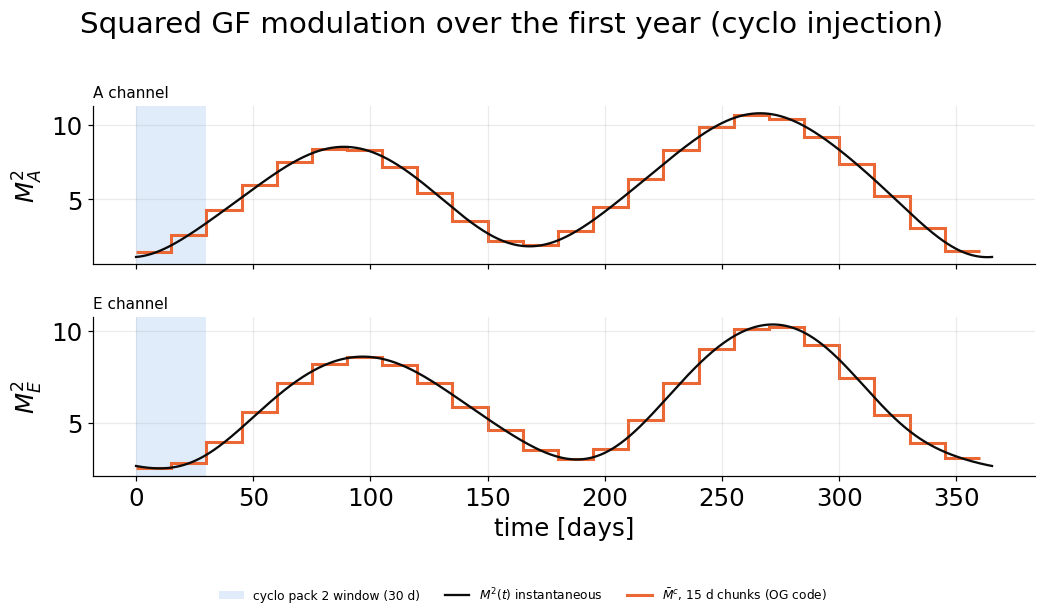

In [4]:
yr = t_hour < YEAR
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    ax.axvspan(0, T_PACK / DAY, color=C_DATA, alpha=0.25, lw=0, label='cyclo pack 2 window (30 d)')
    ax.plot(t_hour[yr] / DAY, P_true[c, yr], color=C_INK, label=r'$M^2(t)$ instantaneous')
    ax.stairs(Pbar_true[c], edges / DAY, baseline=None, color=C_CHUNK, lw=2, label=r'$\bar M^c$, 15 d chunks (OG code)')
    ax.set_ylabel(rf'$M_{ch}^2$')
    ax.set_title(f'{ch} channel', loc='left', fontsize=10)
axes[-1].set_xlabel('time [days]')
fig.suptitle('Squared GF modulation over the first year (cyclo injection)', y=0.99)
bottom_legend(fig, axes[0], ncol=3)
fig.savefig(OUT / 'envelope_vs_chunks.png', bbox_inches='tight')

## 3. Fig. 7 reproduction: a modulated time-domain GF

The original code never builds a modulated time series. It draws each chunk as stationary data with PSD
$\bar M^c S_{\rm GF}$. To get the Fig. 7 picture, we need:

1. a stationary Gaussian process $n_j(t)$ with PSD $S_{\rm GF}(f)$, drawn with the code's own `setting_data.GP_freq` and
   `psd_galaxy.galactic_foreground`. The spectral parameters are pack 2's, and A and E are independent, as in the code;
2. the amplitude modulation $x_j(t) = M_j(t)\,n_j(t)$. Its local variance is $M_j^2(t)\,\sigma^2$, with
   $\sigma^2=\int S_{\rm GF}\,df$, so the chunk average of its periodogram is exactly $\bar M^c S_{\rm GF}$
   (this is checked in §4).

The simulation spans 4 yr at $dt=30$ s, i.e. $4.2\times10^6$ samples per channel. This is coarser than the 10 s of the
config, but the GF has no power above the 16.7 mHz Nyquist frequency (printed below), and 10 s does not fit in memory
here. $M(t)$ varies on timescales of days, so it is evaluated hourly and interpolated.

*Differences from the paper:* paper 1 overlays its envelope on a full LDC simulation (individual DWDs, 4-yr subtraction,
LDC TDI units). Here the GF is the phenomenological spectrum of paper 2 with pack-2 ($T_{\rm obs}=30$ d) parameters, in
`bahamas` TDI units. The *shape* of the envelope is the comparable quantity; the absolute y-scale is not.

In [5]:
T_SIM = 4 * YEAR
DT_TD = 30.                                                 # time-domain cadence (Nyquist 16.7 mHz)
df = 1 / T_SIM
freqs = np.arange(0, 1 / (2 * DT_TD), df)                     # same grid convention as SignalProcessor
gf_spec = {k: GF[k] for k in ('alpha', 'amp', 'fknee', 'fr1', 'fr2')}
S_gf = np.zeros_like(freqs)
S_gf[1:] = np.asarray(gal.galactic_foreground(freqs[1:], gf_spec))
sigma = np.sqrt(np.sum(S_gf) * df)                          # std of the stationary process
f_hi = np.linspace(1 / (2 * DT_TD), 1 / (2 * DT), 10000)
print(f"GF power above Nyquist / below: {np.sum(np.asarray(gal.galactic_foreground(f_hi, gf_spec))) * (f_hi[1] - f_hi[0]) / sigma**2:.1e}")

t_sim = np.arange(2 * len(freqs)) * DT_TD
np.random.seed(SEED)                                         # GP_freq draws from the global numpy RNG
x = {}
for c, ch in enumerate('AE'):
    _, n = setting_data.GP_freq(freqs, DT_TD, S_gf, time=True)
    print(f"{ch}: std(n) / sigma = {n.std() / sigma:.4f}")
    x[ch] = np.sqrt(np.interp(t_sim, t_hour, P_true[c])) * n
    del n
del freqs, S_gf
print(f"N = {len(t_sim):,} samples per channel, sigma = {sigma:.3e}")

GF power above Nyquist / below: 0.0e+00


A: std(n) / sigma = 1.0001


E: std(n) / sigma = 0.9999
N = 4,207,680 samples per channel, sigma = 1.091e-22


Each channel below is drawn as the per-hour min/max of the 30 s series, which looks the same as plotting all samples.
The ink line is $\pm 3\sigma M_j(t)$. With 120 samples per hour, about one sample in three hours lands beyond $3\sigma$, so the
envelope should sit just at the edge of the band.

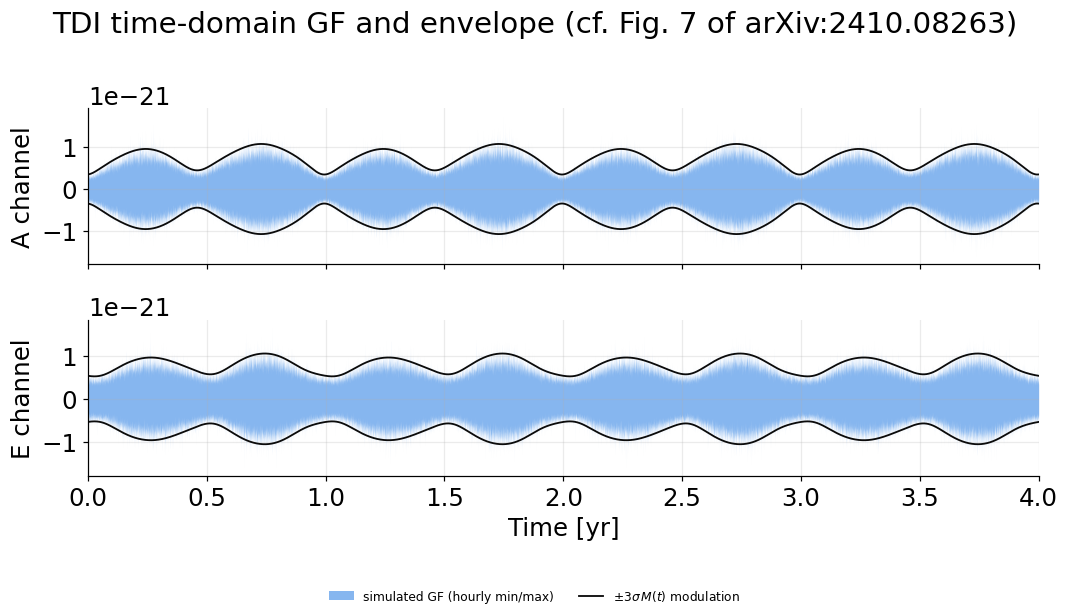

In [6]:
BIN = int(3600 / DT_TD)
t_bin = t_sim[::BIN] / YEAR
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    xb = x[ch].reshape(-1, BIN)
    ax.fill_between(t_bin, xb.min(1), xb.max(1), color=C_DATA, lw=0, label='simulated GF (hourly min/max)', rasterized=True)
    env = 3 * sigma * np.sqrt(P_true[c])
    ax.plot(t_hour / YEAR, env, color=C_INK, lw=1.2, label=r'$\pm3\sigma\,M(t)$ modulation')
    ax.plot(t_hour / YEAR, -env, color=C_INK, lw=1.2)
    ax.set_ylabel(f'{ch} channel')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[-1].set_xlabel('Time [yr]')
axes[-1].set_xlim(0, 4)
fig.suptitle('TDI time-domain GF and envelope (cf. Fig. 7 of arXiv:2410.08263)', y=0.99)
bottom_legend(fig, axes[0], ncol=2)
fig.savefig(OUT / 'fig7_reproduction.png', bbox_inches='tight', dpi=150)

**Zoom on the pack-2 window.** Over 30 days the true envelope drifts. The chunked model replaces it with one constant
level per 15-day chunk, which is the approximation that a time–frequency (wavelet) representation should lift.

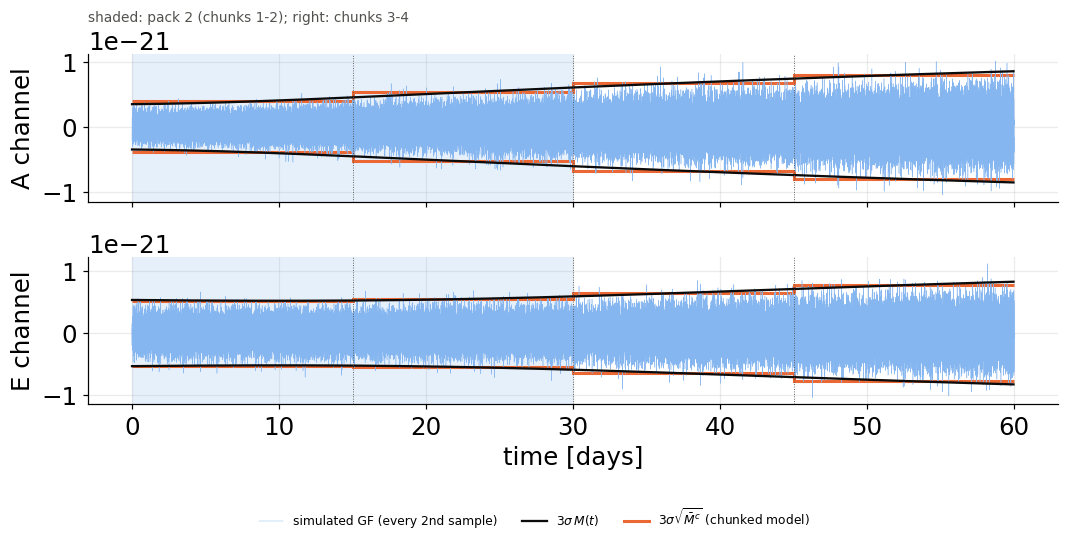

In [7]:
win = t_sim < 2 * T_PACK
th = t_hour < 2 * T_PACK
pack_edges_2x = np.arange(0, 2 * T_PACK + 1, T_CHUNK)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    ax.axvspan(0, T_PACK / DAY, color=C_DATA, alpha=0.2, lw=0)
    ax.plot(t_sim[win][::2] / DAY, x[ch][win][::2], color=C_DATA, lw=0.3, rasterized=True, label='simulated GF (every 2nd sample)')
    ax.plot(t_hour[th] / DAY, 3 * sigma * np.sqrt(P_true[c][th]), color=C_INK, label=r'$3\sigma\,M(t)$')
    ax.plot(t_hour[th] / DAY, -3 * sigma * np.sqrt(P_true[c][th]), color=C_INK)
    lev = 3 * sigma * np.sqrt(chunk_power(GF, pack_edges_2x[:-1], pack_edges_2x[1:], c))
    ax.stairs(lev, pack_edges_2x / DAY, baseline=None, color=C_CHUNK, lw=2, label=r'$3\sigma\sqrt{\bar M^c}$ (chunked model)')
    ax.stairs(-lev, pack_edges_2x / DAY, baseline=None, color=C_CHUNK, lw=2)
    for e in pack_edges_2x[1:-1]:
        ax.axvline(e / DAY, color=C_MUTED, lw=0.6, ls=':')
    ax.set_ylabel(f'{ch} channel')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[0].set_title('shaded: pack 2 (chunks 1-2); right: chunks 3-4', loc='left', fontsize=9, color=C_MUTED)
axes[-1].set_xlabel('time [days]')
bottom_legend(fig, axes[0], ncol=3)
fig.savefig(OUT / 'pack2_window_zoom.png', bbox_inches='tight', dpi=150)

## 4. Consistency with the original chunked pipeline

**(a) Original `SignalProcessor` on Riccardo's exact config.** Only the output paths are redirected to
`data/cyclo_fig7_outputs/`. This reproduces the input of the cyclo run: two 15 d chunks, log-binned periodograms, each
compared with its own model $\bar M^c S_{\rm GF} + S_n$.

2026-10-08 18:01:39,541 - BAHAMAS - INFO - Production of chunked data


2026-10-08 18:01:40,329 - BAHAMAS - INFO - Data saved in /home/krishna/bahamas_ska/data/cyclo_fig7_outputs/data_pack2.h5 and /home/krishna/bahamas_ska/data/cyclo_fig7_outputs/data_pack2_bin.h5


2026-10-08 18:01:40,330 - BAHAMAS - INFO - Saving start and end of chunk.


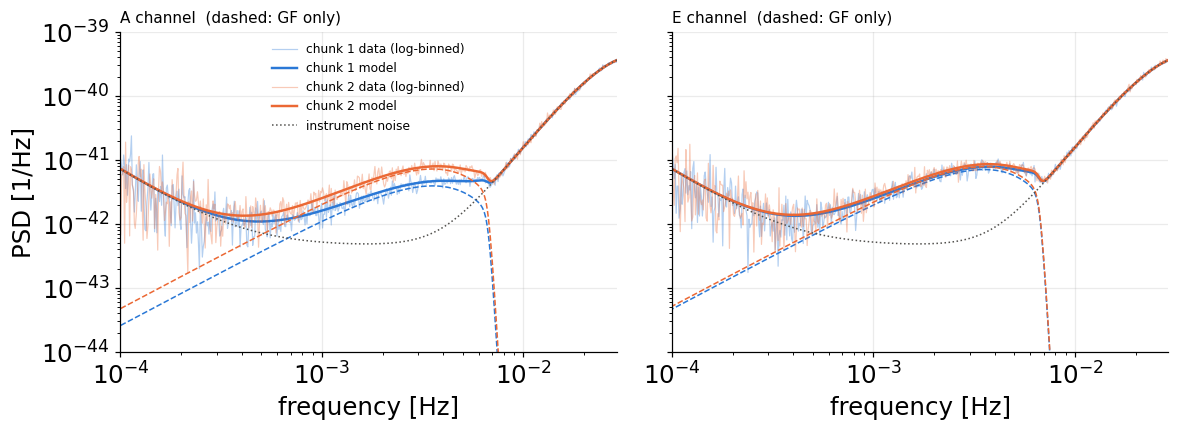

In [8]:
cfg = dict(config, file=str(OUT / 'data_pack2'), fileAV=str(OUT / 'data_pack2_bin'), folder_plot=str(OUT) + '/')
np.random.seed(SEED)
proc = bahamas_data.SignalProcessor(cfg, sources)
proc.handle_series()
proc.simulate_data()
proc.save_data()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    for i, col in enumerate((C_DATA_DARK, C_CHUNK)):
        f = proc.f_av[i]
        tot, parts = psd.model_psd(f, sources, response=np.zeros_like(f), injected=True,
                                   t1=proc.T1[i], t2=proc.T2[i], tdi=c, gen2=False)
        ax.loglog(f, proc.dataAV[i][c], color=col, alpha=0.35, lw=0.8, label=f'chunk {i+1} data (log-binned)')
        ax.loglog(f, np.asarray(tot), color=col, lw=1.6, label=f'chunk {i+1} model')
        ax.loglog(f, np.asarray(parts['galactic_DWD_time']), color=col, lw=1, ls='--')
    ax.loglog(f, np.asarray(parts['instr_noise']), color=C_MUTED, lw=1, ls=':', label='instrument noise')
    ax.set_xlim(config['f1'], config['f2'])
    ax.set_ylim(1e-44, 1e-39)
    ax.set_xlabel('frequency [Hz]')
    ax.set_title(f'{ch} channel  (dashed: GF only)', loc='left', fontsize=10)
axes[0].set_ylabel('PSD [1/Hz]')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'pack2_chunk_spectra.png', bbox_inches='tight')

**(b) Recovering the modulation from the time-domain realisation.** If $x_j(t)=M_j(t)\,n_j(t)$ is right, then

* the 15 d periodograms of $x_j$, divided by $S_{\rm GF}$ and averaged over 0.1–2 mHz, give $\bar M^c$ (orange points);
* a 1-day running mean of $x_j^2/\sigma^2$ tracks $M_j^2(t)$ directly (light-blue line). This is a non-parametric envelope
  estimate, the closest thing in the old framework to what the wavelet stage will do.

A: chunk-average residuals (est - true)/err: mean -0.52, std 0.88
E: chunk-average residuals (est - true)/err: mean +0.06, std 0.78


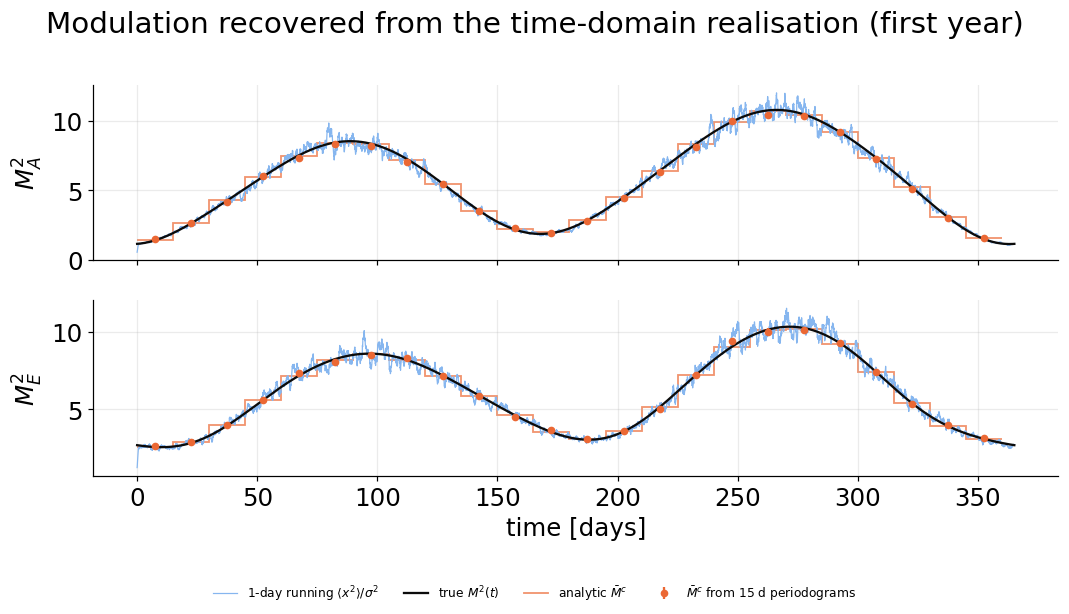

In [9]:
Nc = int(T_CHUNK / DT_TD)
fc = np.fft.rfftfreq(Nc, DT_TD)
band = (fc >= 1e-4) & (fc <= 2e-3)
S_band = np.asarray(gal.galactic_foreground(fc[band], gf_spec))

Pbar_hat, Pbar_err = np.zeros((2, n_chunks_yr)), np.zeros((2, n_chunks_yr))
for c, ch in enumerate('AE'):
    for k in range(n_chunks_yr):
        seg = x[ch][k * Nc:(k + 1) * Nc]
        per = 2 * DT_TD / Nc * np.abs(np.fft.rfft(seg)) ** 2   # one-sided PSD estimate
        r = per[band] / S_band
        Pbar_hat[c, k], Pbar_err[c, k] = r.mean(), r.std() / np.sqrt(r.size)

DAY_BINS = 24
hourly_pow = np.stack([(x[ch].reshape(-1, BIN) ** 2).mean(1) for ch in 'AE']) / sigma ** 2
running = np.stack([np.convolve(h, np.ones(DAY_BINS) / DAY_BINS, mode='same') for h in hourly_pow])

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
mid = 0.5 * (edges[:-1] + edges[1:]) / DAY
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    ax.plot(t_hour[yr] / DAY, running[c, yr], color=C_DATA, lw=0.8, label=r'1-day running $\langle x^2\rangle/\sigma^2$')
    ax.plot(t_hour[yr] / DAY, P_true[c, yr], color=C_INK, label=r'true $M^2(t)$')
    ax.stairs(Pbar_true[c], edges / DAY, baseline=None, color=C_CHUNK, lw=1.2, alpha=0.7, label=r'analytic $\bar M^c$')
    ax.errorbar(mid, Pbar_hat[c], yerr=Pbar_err[c], fmt='o', ms=4, color=C_CHUNK, label=r'$\bar M^c$ from 15 d periodograms')
    ax.set_ylabel(rf'$M_{ch}^2$')
    chi = (Pbar_hat[c] - Pbar_true[c]) / Pbar_err[c]
    print(f"{ch}: chunk-average residuals (est - true)/err: mean {chi.mean():+.2f}, std {chi.std():.2f}")
axes[-1].set_xlabel('time [days]')
fig.suptitle('Modulation recovered from the time-domain realisation (first year)', y=0.99)
bottom_legend(fig, axes[0], ncol=4)
fig.savefig(OUT / 'modulation_recovery_td.png', bbox_inches='tight')

## 5. Riccardo's pack-2 inference → posterior-predictive envelope

`result.hdf5` is the nessai output for pack 2: 12 parameters, the Gamma likelihood and the quasi-stationary model.
Pushing the posterior of the sky parameters $(\sin\beta,\lambda,\sin\psi,\sigma_1^2,\sigma_2^2)$ through
`envelopes_gaussian` shows which envelope 30 days of data support. The same picture is what the wavelet fit will
eventually be compared against.

In [10]:
with h5py.File(CYCLO / 'result.hdf5', 'r') as f:
    post = f['posterior_samples'][()]
    logZ, dlogZ = f['log_evidence'][()], f['log_evidence_error'][()]
print(f"{len(post)} posterior samples, log Z = {logZ:.2f} +/- {dlogZ:.2f}\n")
truth = {**GF, **NOISE}
print(f"{'param':6s} {'truth':>9s} {'median':>9s} {'5%':>9s} {'95%':>9s}")
for k in truth:
    q = np.percentile(post[k], [5, 50, 95])
    print(f"{k:6s} {truth[k]:+9.4f} {q[1]:+9.4f} {q[0]:+9.4f} {q[2]:+9.4f}")

11537 posterior samples, log Z = -132809.47 +/- 0.13

param      truth    median        5%       95%
alpha    +1.8000   +1.9274   +1.8058   +1.9922
amp     -43.9431  -43.9468  -44.0209  -43.8406
fknee    -2.1770   -2.1763   -2.1809   -2.1718
fr1      -2.4290   -2.4157   -2.4298   -2.4064
fr2      -3.4879   -3.5126   -3.6825   -3.3687
lat      -0.0966   -0.1301   -0.2424   -0.0844
long     -1.6259   -1.6990   -1.8596   -1.6250
psi      -0.9900   -0.8419   -0.9751   -0.5537
s1       +0.0416   +0.0291   +0.0030   +0.0722
s2       +0.1384   +0.1623   +0.1059   +0.2874
A        +2.4000   +2.3974   +2.3258   +2.4715
P        +7.9000   +7.8822   +7.8514   +7.9132


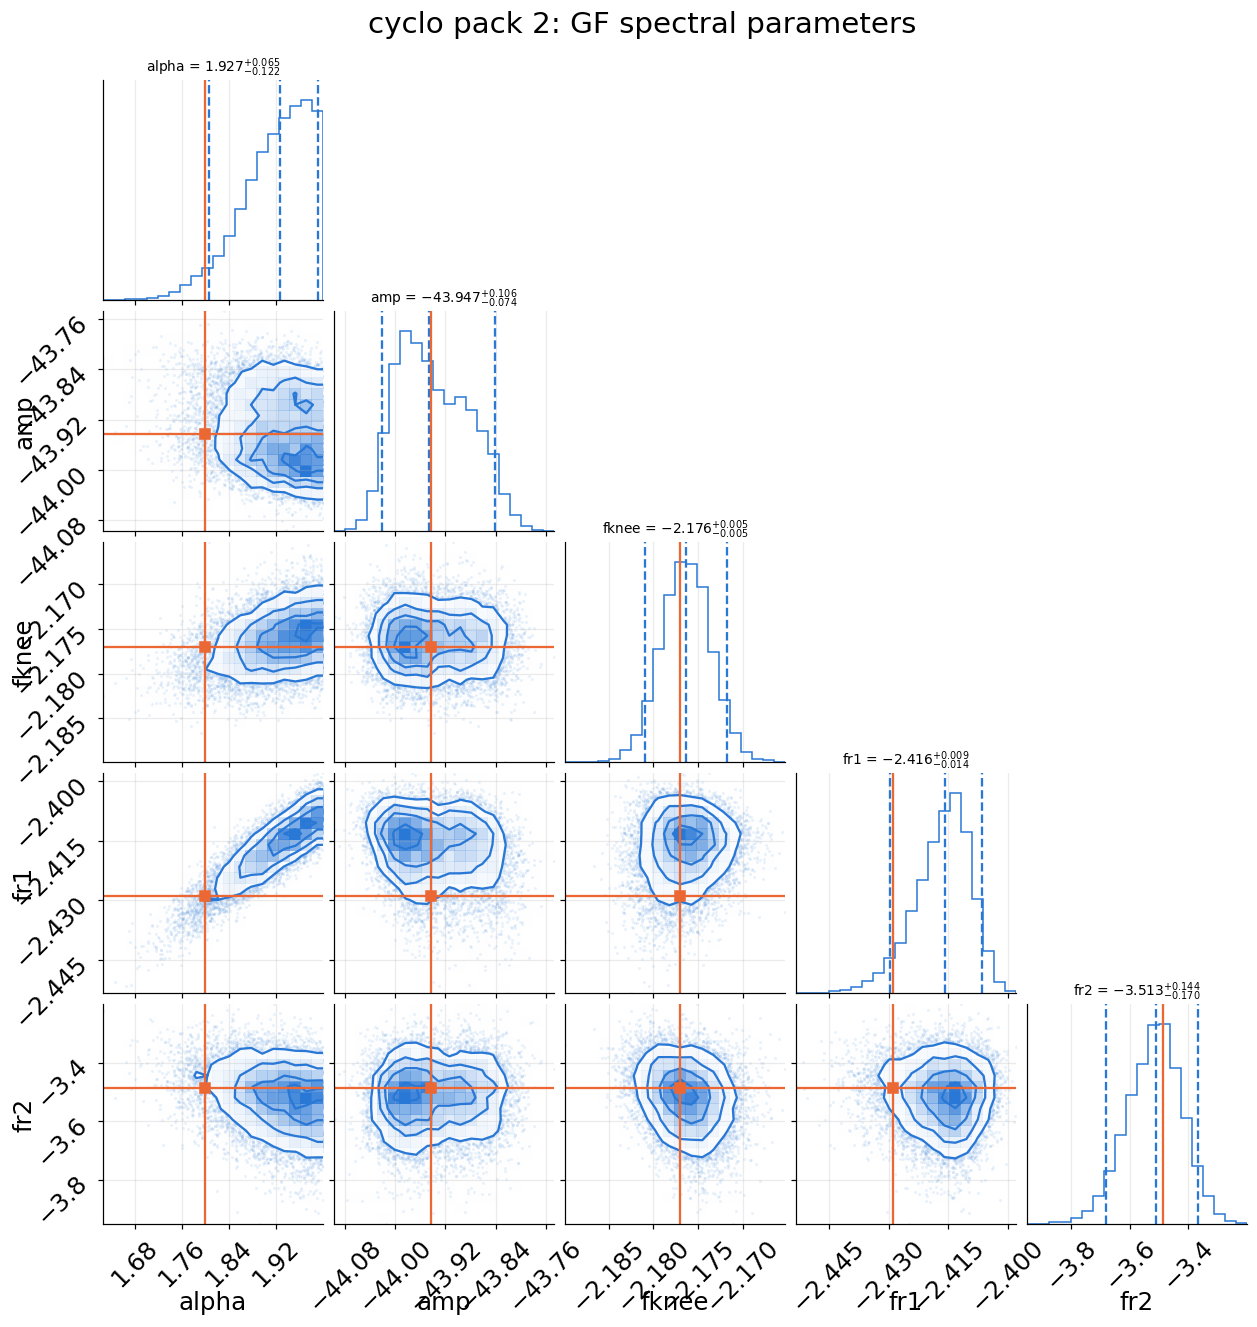

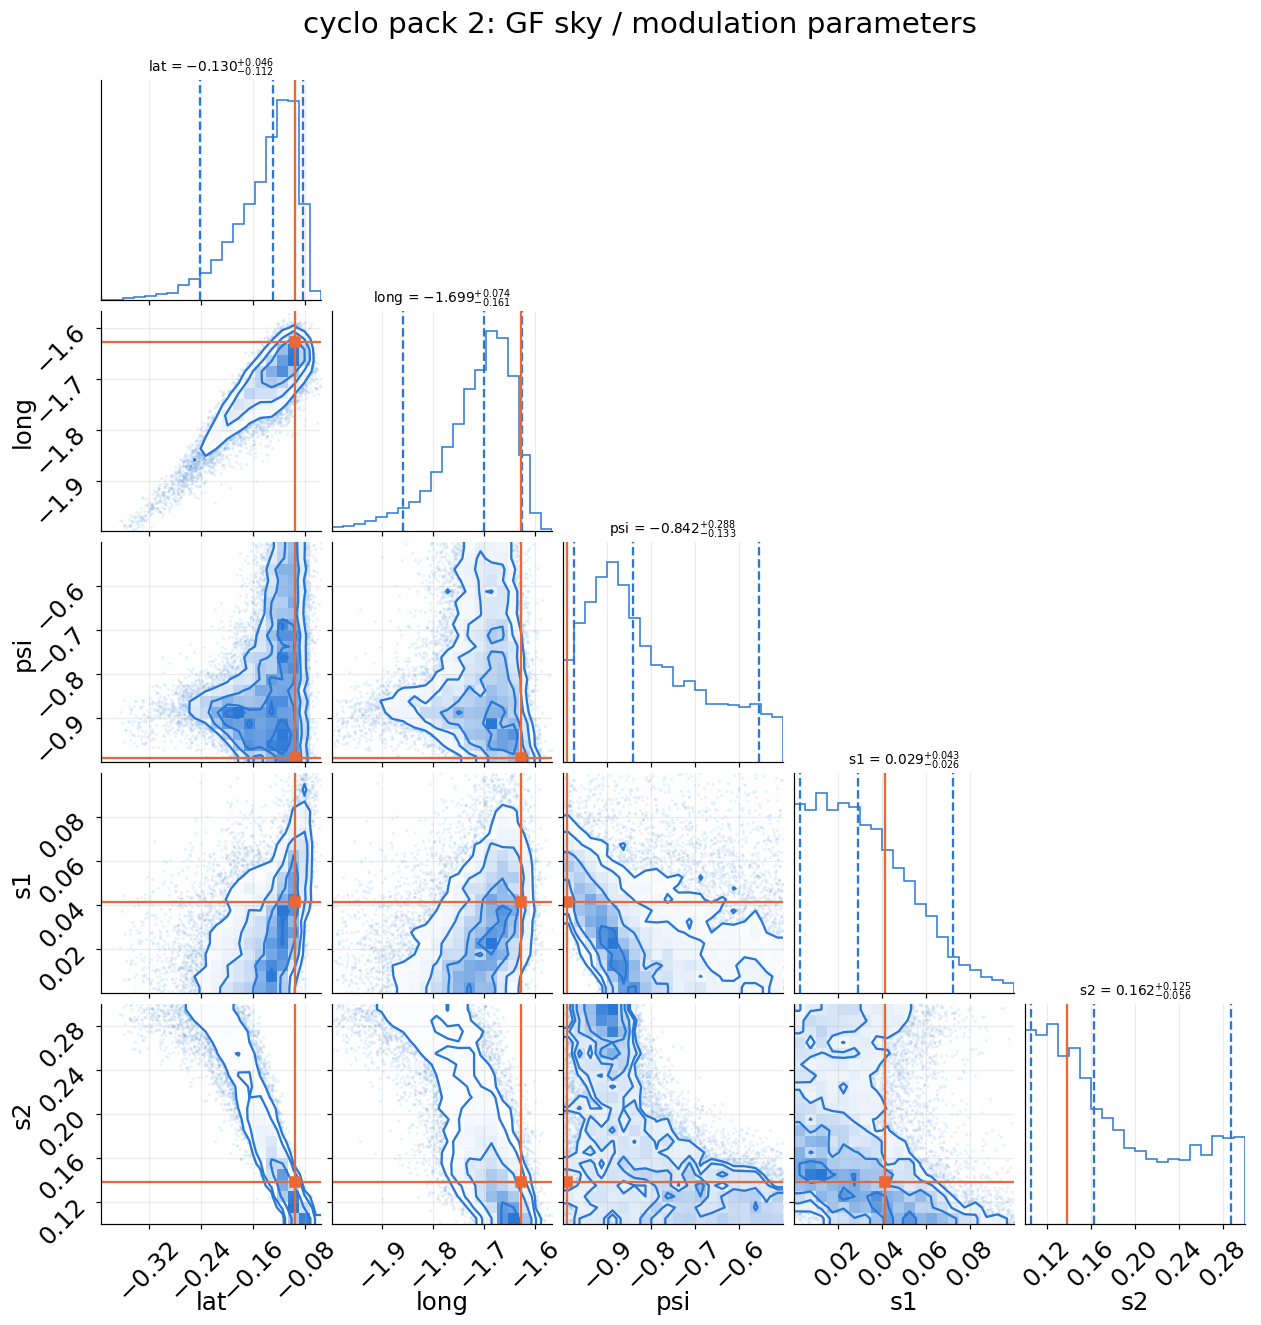

In [11]:
for keys, title, fname in [(['alpha', 'amp', 'fknee', 'fr1', 'fr2'], 'GF spectral parameters', 'corner_spectral.png'),
                           (['lat', 'long', 'psi', 's1', 's2'], 'GF sky / modulation parameters', 'corner_sky.png')]:
    samples = np.column_stack([post[k] for k in keys])
    fig = corner.corner(samples, labels=keys, truths=[truth[k] for k in keys], truth_color=C_CHUNK, color=C_DATA_DARK,
                        quantiles=[0.05, 0.5, 0.95], show_titles=True, title_fmt='.3f', title_kwargs={'fontsize': 9})
    fig.suptitle(f'cyclo pack 2: {title}', y=1.02)
    fig.savefig(OUT / fname, bbox_inches='tight')

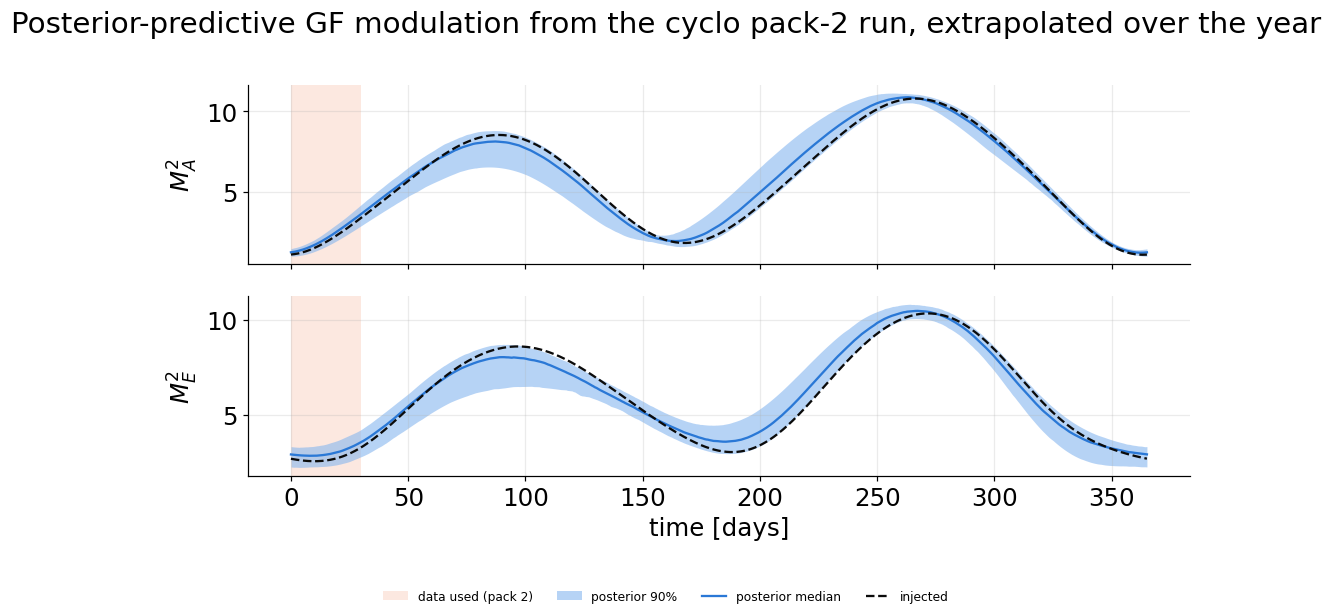

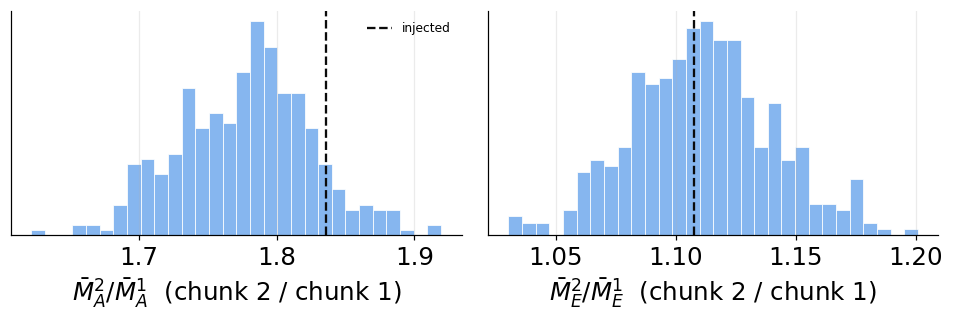

In [12]:
rng = np.random.default_rng(SEED)
draws = post[rng.choice(len(post), 400, replace=False)]
t_pp = np.arange(0, YEAR, 6 * 3600.)
P_pp = np.array([np.stack(modulation_power({k: d[k] for k in ('lat', 'long', 'psi', 's1', 's2')}, t_pp)) for d in draws])
P_truth_pp = np.stack(modulation_power(GF, t_pp))
lo, med, hi = np.percentile(P_pp, [5, 50, 95], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    ax.axvspan(0, T_PACK / DAY, color=C_CHUNK, alpha=0.15, lw=0, label='data used (pack 2)')
    ax.fill_between(t_pp / DAY, lo[c], hi[c], color=C_DATA, alpha=0.6, lw=0, label='posterior 90%')
    ax.plot(t_pp / DAY, med[c], color=C_DATA_DARK, label='posterior median')
    ax.plot(t_pp / DAY, P_truth_pp[c], color=C_INK, ls='--', label='injected')
    ax.set_ylabel(rf'$M_{ch}^2$')
axes[-1].set_xlabel('time [days]')
fig.suptitle('Posterior-predictive GF modulation from the cyclo pack-2 run, extrapolated over the year', y=0.99)
bottom_legend(fig, axes[0], ncol=4)
fig.savefig(OUT / 'posterior_predictive_envelope.png', bbox_inches='tight')

# The data constrain the chunk-to-chunk modulation inside the pack directly: chunk 2 / chunk 1 power ratio
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for c, (ax, ch) in enumerate(zip(axes, 'AE')):
    ratio = np.array([np.divide(*chunk_power({k: d[k] for k in ('lat', 'long', 'psi', 's1', 's2')},
                                             pack_edges[:-1], pack_edges[1:], c)[::-1]) for d in draws])
    tr = np.divide(*chunk_power(GF, pack_edges[:-1], pack_edges[1:], c)[::-1])
    ax.hist(ratio, bins=30, color=C_DATA, edgecolor='white', linewidth=0.5)
    ax.axvline(tr, color=C_INK, ls='--', label='injected')
    ax.set_xlabel(rf'$\bar M^2_{ch}/\bar M^1_{ch}$  (chunk 2 / chunk 1)')
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.tight_layout()

## 6. Where Fig. A2 / Fig. 6 sit on the modulation

In the differential analysis of paper 2 the year is cut into two-week packs. Each pack has two one-week chunks and is
analysed independently. The pack evidence tracks $d^2M_A^2/dt^2$ (Fig. 6, right), and Fig. A2 compares packs 7, 16 and 26.
Below, those packs are placed on the true modulation, together with the cyclo sequential pack 2. This assumes pack $k$
spans $[(k-1)\Delta,\,k\Delta]$ with $\Delta = 1\,{\rm yr}/26$; Riccardo should confirm the exact indexing. The two
quantities have different units, so they get separate panels.

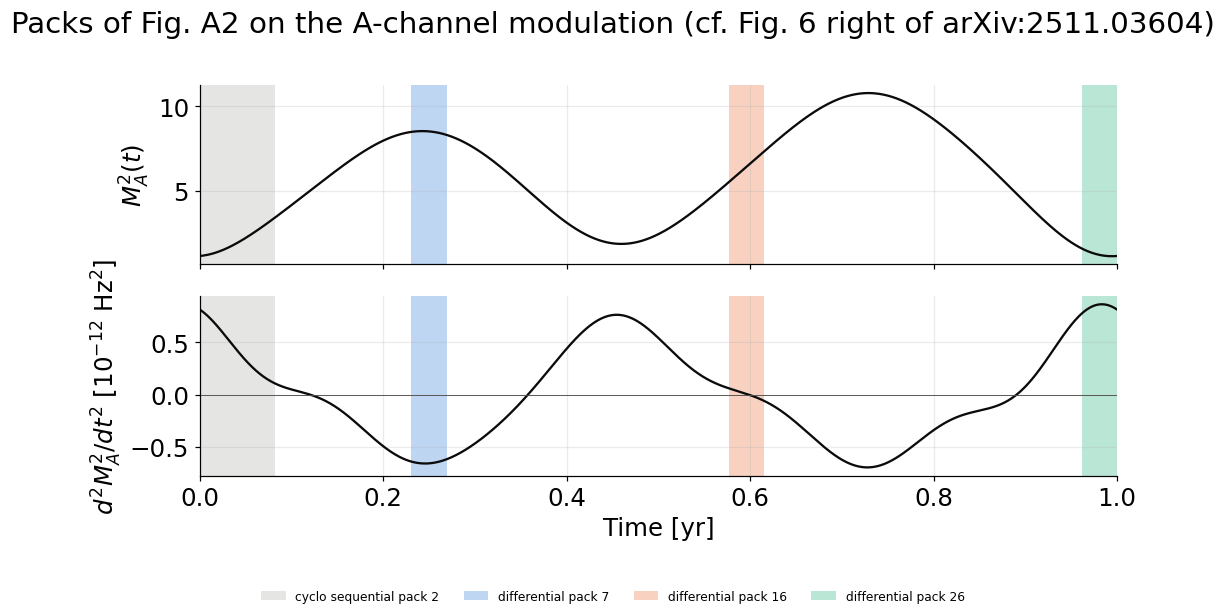

In [13]:
d2 = np.gradient(np.gradient(P_true[0], t_hour), t_hour)
DELTA = YEAR / 26
packs = {7: C_DATA_DARK, 16: C_CHUNK, 26: C_CHUNK2}

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, y, lab in [(axes[0], P_true[0], r'$M_A^2(t)$'), (axes[1], d2 / 1e-12, r'$d^2M_A^2/dt^2$ [$10^{-12}$ Hz$^2$]')]:
    ax.plot(t_hour[yr] / YEAR, y[yr], color=C_INK)
    ax.set_ylabel(lab)
    ax.axvspan(0, T_PACK / YEAR, color=C_MUTED, alpha=0.15, lw=0, label='cyclo sequential pack 2')
    for k, col in packs.items():
        ax.axvspan((k - 1) * DELTA / YEAR, k * DELTA / YEAR, color=col, alpha=0.3, lw=0, label=f'differential pack {k}')
axes[1].axhline(0, color=C_MUTED, lw=0.6)
axes[-1].set_xlabel('Time [yr]')
axes[-1].set_xlim(0, 1)
fig.suptitle('Packs of Fig. A2 on the A-channel modulation (cf. Fig. 6 right of arXiv:2511.03604)', y=0.99)
bottom_legend(fig, axes[0], ncol=4)
fig.savefig(OUT / 'figA2_pack_context.png', bbox_inches='tight')

## 7. Save the products for the wavelet stage

`data/cyclo_fig7_outputs/gf_modulation_truth.npz` holds:

* the true $P_j(t)=M_j^2(t)$ on an hourly grid over 4 yr, which is the target a wavelet modulation model should reproduce;
* the analytic chunk averages and the time-domain estimates for the 24 first-year chunks;
* the modulated time-domain realisation over the first 60 d (pack 2 plus the next 30 d) at $dt=30$ s, plus the seed;
* all injected parameters.

The chunked pack-2 data from the original pipeline are in `data_pack2*.h5`.

In [14]:
keep = t_sim < 2 * T_PACK
np.savez_compressed(
    OUT / 'gf_modulation_truth.npz',
    t_hour=t_hour, P_A=P_true[0], P_E=P_true[1],
    chunk_edges=edges, Pbar_A=Pbar_true[0], Pbar_E=Pbar_true[1],
    Pbar_hat_A=Pbar_hat[0], Pbar_hat_E=Pbar_hat[1], Pbar_err_A=Pbar_err[0], Pbar_err_E=Pbar_err[1],
    t_td=t_sim[keep], x_A=x['A'][keep], x_E=x['E'][keep], dt=DT_TD, sigma=sigma, seed=SEED,
    pack_T=T_PACK, chunk_T=T_CHUNK,
    gf_params=np.array(list(GF.items()), dtype=object), noise_params=np.array(list(NOISE.items()), dtype=object),
)
print(sorted(p.name for p in OUT.iterdir()))

['corner_sky.png', 'corner_spectral.png', 'data_pack2.h5', 'data_pack2_bin.h5', 'envelope_vs_chunks.png', 'fig7_reproduction.png', 'figA2_pack_context.png', 'gf_modulation_truth.npz', 'modulation_recovery_td.png', 'pack2_chunk_spectra.png', 'pack2_window_zoom.png', 'posterior_predictive_envelope.png', 'time_interval.txt']


## Next: the wavelet stage

The truth to aim for is the ink $M^2(t)$ curve, the pack-2 window in particular. The steps are:

1. Fit `bahamas.wavelet.model.WaveletModulation` ($\log P(t)=b+\sum_k a_k\,\psi((t-t_k)/\tau_k)$) to the true $P_j(t)$ on
   the pack-2 window. This shows how many atoms, and of what width, represent the 30-day drift.
2. Use that representation as the injection/model in the WDM pipeline (`modulation: wavelets`), run the inference on the
   pack-2 data, and check that the injected envelope is recovered. Compare with the posterior-predictive band of §5 from
   the chunked run.